In [1]:
from decimal import Decimal, ROUND_UP
import numpy as np
def round_up(number, precision, output_type=Decimal):
    decimal_number = Decimal(str(number))
    decimal_precision = Decimal(str(precision))
    rounded_number = decimal_number.quantize(decimal_precision, rounding=ROUND_UP)
    if output_type != Decimal:
        return output_type(rounded_number)
    return rounded_number

def err_rp(value, nonzero_digits = 1, output_type=Decimal):
    # find first non-zero digit position
    nz_pos = np.floor(np.log10(abs(value)))
    return round_up(value, 10**(nz_pos-nonzero_digits+1), output_type=output_type)

In [2]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import map_coordinates

# Load the F200W, F356W, and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F356W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
headers = [hdul[0].header for hdul in hduls]
pixel_scales = [header['PIXSCALE'] for header in headers]
data = [hdul[0].data for hdul in hduls]
hpfrdi_images = [d[:,:,1] for d in data]
deconv_images = [d[:,:,0] for d in data]

VOTable Version of Star Photometry Data:


/npool/nvme/yuchialin/miniconda3/envs/spaceklip/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


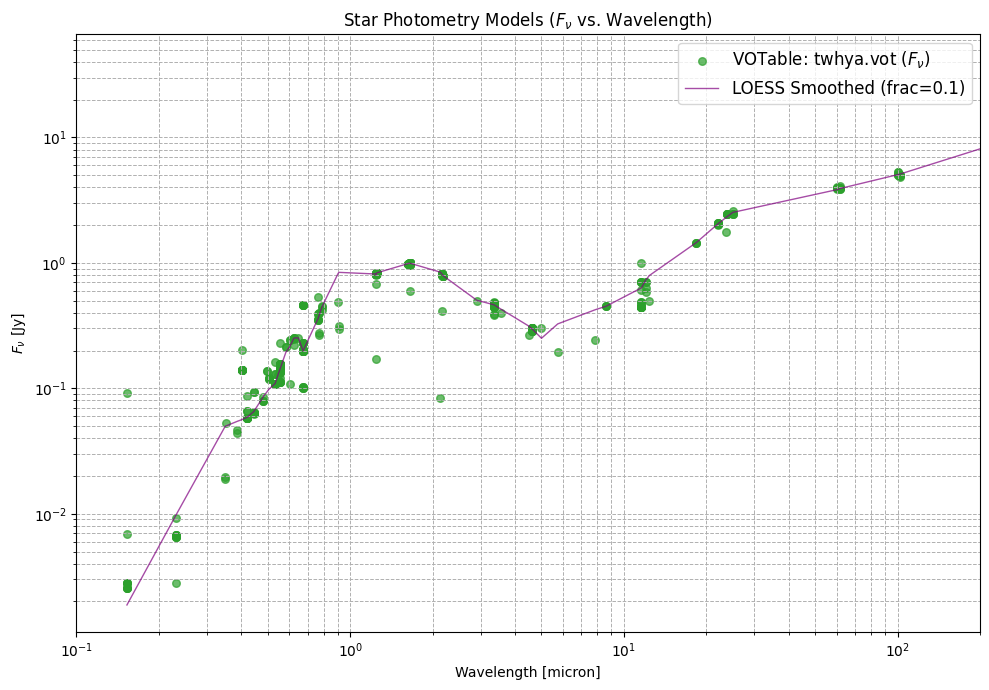

In [3]:
# Plot the Tw Hya Vega Magnitude vs Wavelength
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import statsmodels.api as sm

star_photometry_vot = 'twhya.vot'  # VOTable.
vega_photometry_vot = 'vega.vot'  # Vega magnitude reference.
star_spectral_type = 'M0V'  # Spectral type.

# Read in the VOTable version of the star photometry data.
star_vot = Table.read(star_photometry_vot)

# Convert frequency to wavelength (microns) for plotting.
star_vot["wavelength"] = (const.c / star_vot["sed_freq"]).to(u.micron)

print("VOTable Version of Star Photometry Data:")
star_vot.to_pandas()  # For an easier to read output.

# Constants
c = 299792458.0  # Speed of light in m/s
Jy_to_Wm2Hz = 1e-26  # Conversion factor for Jansky to W/m^-2/Hz^-1
micron_to_m = 1e-6   # Conversion factor for micron to m

# Extract data from your star_vot
star_wavelength_microns = star_vot["wavelength"]
star_sed_flux_jansky = star_vot["sed_flux"]

# Sort the data by wavelength for smoothing
sorted_indices = np.argsort(star_wavelength_microns)
star_wavelength_microns_sorted = star_wavelength_microns[sorted_indices]
star_sed_flux_jansky_sorted = star_sed_flux_jansky[sorted_indices]

# Smoothing the data using LOESS (Locally Estimated Scatterplot Smoothing)
# The 'frac' parameter controls the smoothness.
# It's the fraction of data used for each local regression.
# Adjust this value (e.g., 0.1 to 0.5) to change smoothness.
frac_value = 0.1
smoothed_star_sed_flux_jansky = sm.nonparametric.lowess(star_sed_flux_jansky_sorted, star_wavelength_microns_sorted, frac=frac_value)
smoothed_x = smoothed_star_sed_flux_jansky[:, 0]
smoothed_y = smoothed_star_sed_flux_jansky[:, 1]

# Final Plotting
# --- Figure Configuration ---
plt.figure(figsize=(10, 7)) # Slightly larger for better readability

# Plot the star photometry data
plt.scatter(
    star_wavelength_microns, # X-axis remains wavelength in microns
    star_sed_flux_jansky,
    label=r"VOTable: twhya.vot ($F_{\nu}$)", # Use LaTeX for nu F_nu
    color="C2", # Changed color for distinction if you plot both
    s=30,       # Marker size
    alpha=0.7   # Marker transparency
)

# Plot the LOESS smoothed curve
plt.plot(
    smoothed_x,
    smoothed_y,
    color='purple', # A distinct color for the smooth line
    linewidth=1,
    label=f'LOESS Smoothed (frac={frac_value})',
    alpha=0.7   # Marker transparency
)

plt.xlabel("Wavelength [micron]")
plt.ylabel(r"$F_{\nu}$ [Jy]") # LaTeX for units
plt.legend(fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.xlim(0.1, 2e2)
plt.grid(True, linestyle="--", linewidth=0.7, which="both") # 'which="both"' is good for log scales
plt.title(r"Star Photometry Models ($F_{\nu}$ vs. Wavelength)")

plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()

Fitted line: y = 0.5746$x^2$ + 0.3317x + -0.5598, $R^2$ = 0.98


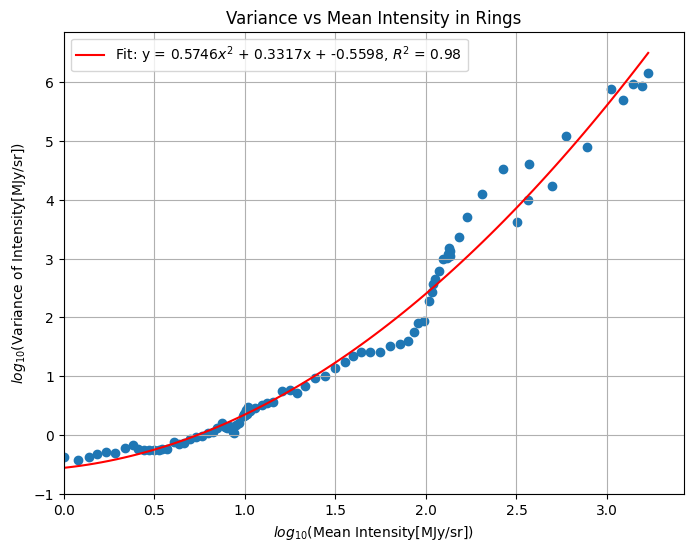

In [4]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# Load the F200W and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
data = [hdul[0].data for hdul in hduls]
images = [d[:,:,0] for d in data]
image_f200w = images[0]

# make a ring clipping mask
r_in = 0  # inner radius in pixels
r_out = 100  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels
rings = [[] for _ in range(r_in, r_out)]
for x,y in np.ndindex(image_f200w.shape):
    r = np.sqrt((x-x_center)**2 + (y-y_center)**2)
    if r_in <= r <= r_out:
        #print(r, int(r)-r_in)
        rings[int(r)-r_in].append(image_f200w[x,y])

# calculate the mean value and var of each ring
ring_means = [np.mean(ring) for ring in rings]
ring_vars = [np.var(ring, ddof=1) for ring in rings]
ring_means_log = np.log10(ring_means)
ring_vars_log = np.log10(ring_vars)

# Fit a line to the data
coefficients = np.polyfit(ring_means_log, ring_vars_log, 2)
polynomial = np.poly1d(coefficients)
R_squared = 1 - (np.sum((ring_vars_log - polynomial(ring_means_log))**2) / np.sum((ring_vars_log - np.mean(ring_vars_log))**2))
print(f"Fitted line: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}")

# Create a scatter plot of var vs mean
plt.figure(figsize=(8, 6))
plt.scatter(ring_means_log, ring_vars_log)
# Plot the fitted line
x_fit = np.linspace(min(ring_means_log), max(ring_means_log), 100)
y_fit = polynomial(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {coefficients[0]:.4f}$x^2$ + {coefficients[1]:.4f}x + {coefficients[2]:.4f}, $R^2$ = {R_squared:.2f}')
plt.legend()
plt.xlabel(f'$log_{{10}}$(Mean Intensity[MJy/sr])')
plt.ylabel(f'$log_{{10}}$(Variance of Intensity[MJy/sr])')
plt.title('Variance vs Mean Intensity in Rings')
plt.grid(True)
plt.xlim(0,)
plt.ylim(-1,)
plt.show()

HPFRDI Images Photometry
Filter: F200W


Processing took: 12.0912 seconds
Mean Total Flux: 8.27 mJy
Standard Deviation of Total Flux: 0.004 mJy


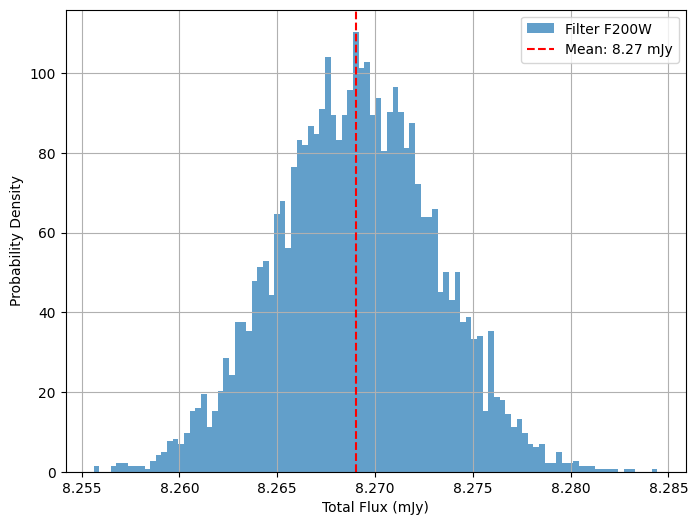

Filter: F356W
Processing took: 8.6010 seconds
Mean Total Flux: 2.19 mJy
Standard Deviation of Total Flux: 0.004 mJy


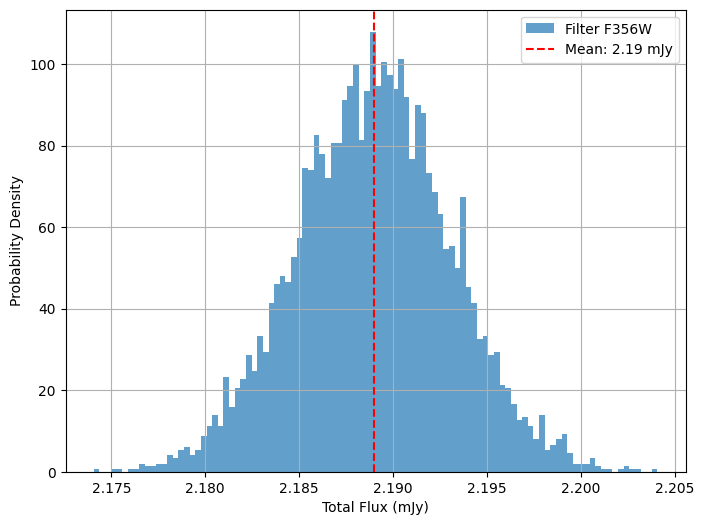

Filter: F444W
Processing took: 8.4782 seconds
Mean Total Flux: 1.17 mJy
Standard Deviation of Total Flux: 0.006 mJy


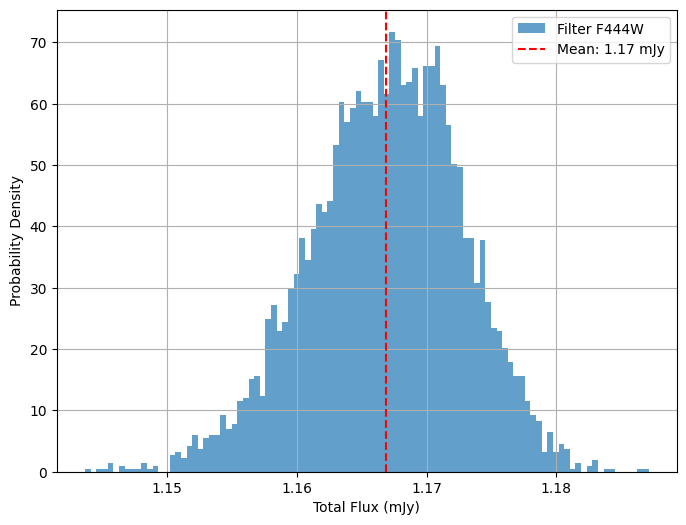



Deconvolved Images Photometry
Filter: F200W
Processing took: 11.5563 seconds
Mean Total Flux: 20.06 mJy
Standard Deviation of Total Flux: 0.307 mJy


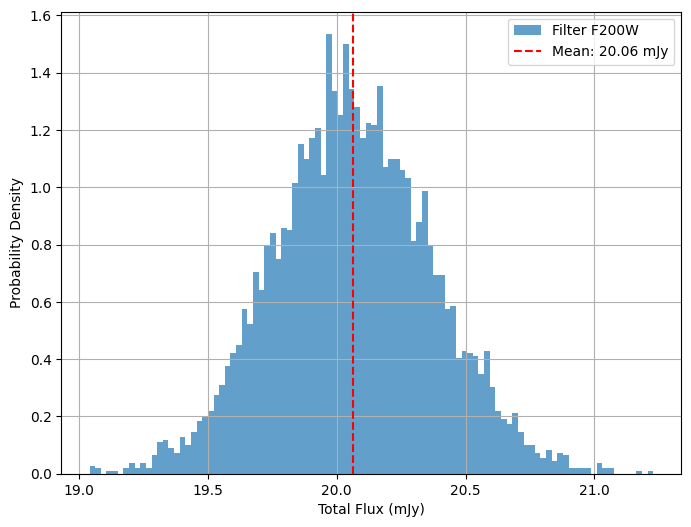

Filter: F356W
Processing took: 8.4115 seconds
Mean Total Flux: 3.42 mJy
Standard Deviation of Total Flux: 0.090 mJy


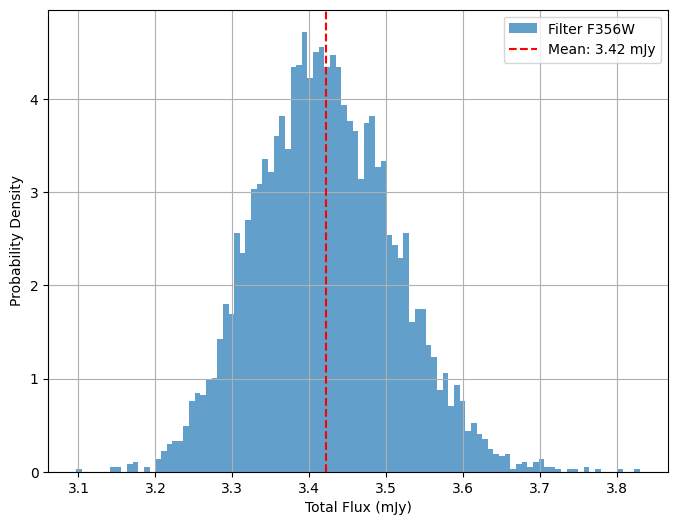

Filter: F444W
Processing took: 7.5720 seconds
Mean Total Flux: 3.16 mJy
Standard Deviation of Total Flux: 0.069 mJy


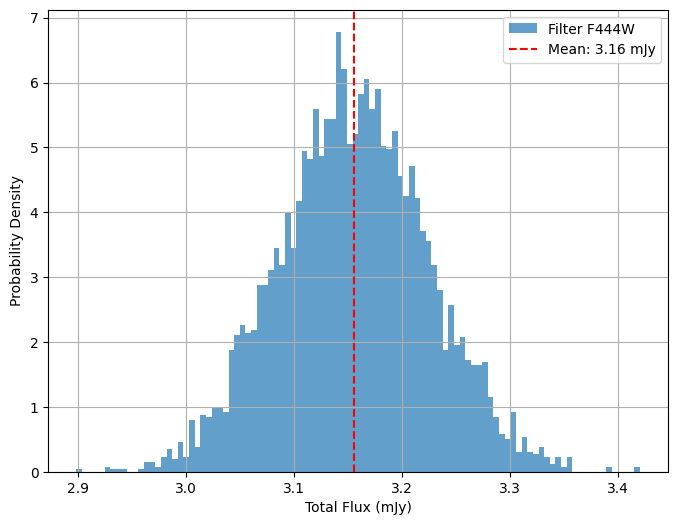

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Setting for a ring clipping mask
r_in = [0,0,0,0]  # inner radius in pixels
r_out = [324,324,324,324]  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels

# Constant
conversion_factor = 2.3504e-2 # mJy/arcsec^2 per MJy/sr

# --- Bootstrap analysis ---
n_bootstrap = 5000 # Number of bootstrap samples

def bootstrap_photometry(images, headers, pixel_scales, n_bootstrap):
    """
    Performs bootstrap photometry on a list of images.
    """
    bootstrap_fluxes = np.empty(len(images))
    bootstrap_efluxes = np.empty(len(images))
    for i, (image, header, pixel_scale) in enumerate(zip(images, headers, pixel_scales)):
        start_time = time.time()
        if 'filter' in header:
            print(f"Filter: {header['filter']}")
        # 1. Vectorized Grid and Radius Calculation
        ny, nx = image.shape
        y_indices, x_indices = np.mgrid[:ny, :nx]
        radii = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)

        # 2. Fast Pixel Grouping into Rings
        # Create a mask for pixels within the desired radial range and that are not NaN
        valid_mask = (radii >= r_in[i]) & (radii < r_out[i]) & ~np.isnan(image)
        
        # Get the pixel values and their corresponding integer ring number
        valid_pixels = image[valid_mask]
        valid_radii_integers = radii[valid_mask].astype(int)

        # Get unique ring numbers and the indices to reconstruct them
        unique_rings, ring_indices = np.unique(valid_radii_integers, return_inverse=True)
        
        # 3. Vectorized Bootstrap Resampling
        # Create an array to store the sum of each bootstrap sample
        bootstrap_sums = np.zeros(n_bootstrap)
        
        # Loop through each ring, perform bootstrap on its pixels, and add to total
        for ring_num in unique_rings:
            # Find all pixels that belong to the current ring
            pixels_in_ring = valid_pixels[valid_radii_integers == ring_num]
            n_pixels = len(pixels_in_ring)
            if n_pixels == 0:
                continue

            # Generate all bootstrap samples for this ring in one go
            # Shape: (n_pixels_in_ring, n_bootstrap)
            resampled_indices = np.random.randint(0, n_pixels, size=(n_pixels, n_bootstrap))
            resampled_pixels = pixels_in_ring[resampled_indices]
            
            # Sum each bootstrap column and add it to our running total
            bootstrap_sums += np.sum(resampled_pixels, axis=0)

        # 4. Final Flux Calculation
        total_fluxes_bootstrap = bootstrap_sums * (pixel_scale**2) * conversion_factor

        # --- Analysis and Plotting ---
        mean_flux = np.mean(total_fluxes_bootstrap)
        std_flux = np.std(total_fluxes_bootstrap)
        
        end_time = time.time()
        print(f"Processing took: {end_time - start_time:.4f} seconds")
        print(f"Mean Total Flux: {mean_flux:.2f} mJy")
        print(f"Standard Deviation of Total Flux: {std_flux:.3f} mJy")
        
        plt.figure(figsize=(8, 6))
        plt.hist(total_fluxes_bootstrap, bins=100, density=True, alpha=0.7, label=f'Filter {header["filter"]}')
        #plt.title(f'Bootstrap Distribution of Total Brightness - Filter {header["filter"]}')
        plt.xlabel('Total Flux (mJy)')
        plt.ylabel('Probability Density')
        plt.axvline(mean_flux, color='r', linestyle='--', label=f'Mean: {mean_flux:.2f} mJy')
        plt.legend()
        plt.grid(True)
        plt.show()
        bootstrap_fluxes[i] = mean_flux
        bootstrap_efluxes[i] = std_flux
    return bootstrap_fluxes, bootstrap_efluxes

# HPFRDI Images Photometry
print("HPFRDI Images Photometry")
hpfrdi_fluxes = np.empty(len(hpfrdi_images))
hpfrdi_efluxes = np.empty(len(hpfrdi_images))
hpfrdi_fluxes, hpfrdi_efluxes = bootstrap_photometry(hpfrdi_images, headers, pixel_scales, n_bootstrap)

print("\n" + "="*50 + "\n")

# Deconvolved Images Photometry
print("Deconvolved Images Photometry")
deconv_fluxes = np.empty(len(deconv_images))
deconv_efluxes = np.empty(len(deconv_images))
deconv_fluxes, deconv_efluxes = bootstrap_photometry(deconv_images, headers, pixel_scales, n_bootstrap)

In [8]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [9]:
import webbpsf_ext
nrc = webbpsf_ext.NIRCam_ext(filter='F444W', image_mask='MASK335R', pupil_mask='CIRCLYOT')
coron_mask = nrc.gen_mask_image(nd_squares=False, pixelscale=nrc.pixelscale)

[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R


In [10]:
# Calculate total brightness with consideration of coronagraphic mask by dividing by mask transmission
# The image data is in units of surface brightness, MJy/sr
# To get the total brightness (flux density), we need to sum the values of all pixels and multiply by the solid angle of a single pixel.
# The solid angle of a pixel is pixel_scale^2 (in arcsec^2).

# HPFRDI images
print("HPFRDI Images Photometry with Coronagraphic Mask Correction")
print("="*50)
hpfrdi_fluxes_throughput_recover = np.empty(len(hpfrdi_images))
for i, (image, header, pixel_scale) in enumerate(zip(hpfrdi_images, headers, pixel_scales)):
    if 'filter' in header:
        print(f"Filter: {header['filter']}")
        
    # Load the coronagraphic mask corresponding to the filter
    nrc = webbpsf_ext.NIRCam_ext(filter=header['filter'], image_mask='MASK335R', pupil_mask='CIRCLYOT')
    coron_mask = nrc.gen_mask_image(npix=len(image) ,nd_squares=False, pixelscale=pixel_scale)
    
    # Avoid division by zero by setting a minimum transmission
    min_transmission = 0.01
    corrected_mask = np.clip(coron_mask, min_transmission, 1)
    corrected_image = image / corrected_mask
    
    # Savve the corrected image in a FITS file
    fits.writeto(f'throughput_recover_{header["filter"]}.fits', corrected_image, header, overwrite=True)
    
    # Total brightness = sum(pixel values) * pixel_area
    total_brightness = np.nansum(corrected_image) * (pixel_scale**2)
    print(f"Pixel scale: {pixel_scale:.4f} arcsec/pixel")
    print(f"Solid angle per pixel: {pixel_scale**2:.4f} arcsec^2/pixel")
    print(f"Applied minimum mask transmission of {min_transmission} to avoid division by zero.")
    
    if 'BUNIT' in header:
        bunit = header['BUNIT']
        print(f"The surface brightness unit is: {bunit}")
    else:
        print("BUNIT keyword not found in header.")

    # The unit is MJy/sr, we can convert to mJy.
    # 1 sr = (180/pi)^2 * 3600^2 arcsec^2 = 206265^2 arcsec^2
    # 1 MJy = 1e6 Jy = 1e9 mJy
    # So, 1 MJy/sr = 1e9 mJy / (206265^2 arcsec^2) = 2.35e-2 mJy/arcsec^2
    #if 'BUNIT' in header and header['BUNIT'].lower() == 'mjy/sr':
    if True:
        conversion_factor = 2.3504e-2 # mJy/arcsec^2 per MJy/sr
        total_flux_mjy = total_brightness * conversion_factor
        print(f"Total flux in mJy: {total_flux_mjy:.2f} mJy")
        print("="*40)
        hpfrdi_fluxes_throughput_recover[i] = total_flux_mjy

HPFRDI Images Photometry with Coronagraphic Mask Correction
Filter: F200W
[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_MASK335R
Pixel scale: 0.0307 arcsec/pixel
Solid angle per pixel: 0.0009 arcsec^2/pixel
Applied minimum mask transmission of 0.01 to avoid division by zero.
BUNIT keyword not found in header.
Total flux in mJy: 23.72 mJy
Filter: F356W
[     stpsf:INFO] NIRCam aperture name updated to NRCA1_FULL
[     stpsf:INFO] NIRCam pupil mask setter: aperturename NRCA1_FULL
[     stpsf:INFO] NIRCam aperture name updated to NRCA2_FULL_WEDGE_RND
[     stpsf:INFO] NIRCam aperture name updated to NRCA5_FULL_MASK335R
Pixel scale: 0.0624 arcsec/pixel
Solid angle per pixel: 0.0039 arcsec^2/pixel
Applied minim

In [11]:
# Display results in a table
print("\n" + "="*100)
print("Photometry Results with Coronagraphic Mask Correction")
print("-" * 100)
print(f"{'Filter':<10} {'HPFRDI Flux [mJy]':<20} {'HPFRDI Flux Throughput Recover [mJy]':<40} {'Deconvolved Flux [mJy]':<25}")
print("-" * 100)
for i, header in enumerate(headers):
    filter_name = header['filter'] if 'filter' in header else 'Unknown'
    hpfrdi_flux = hpfrdi_fluxes[i]
    deconv_flux = deconv_fluxes[i]
    hpfrdi_flux_throughput_recover =hpfrdi_fluxes_throughput_recover[i]
    print(f"{filter_name:<15} {hpfrdi_flux:<30.2f} {hpfrdi_flux_throughput_recover:<33.2f} {deconv_flux:<25.2f}")


Photometry Results with Coronagraphic Mask Correction
----------------------------------------------------------------------------------------------------
Filter     HPFRDI Flux [mJy]    HPFRDI Flux Throughput Recover [mJy]     Deconvolved Flux [mJy]   
----------------------------------------------------------------------------------------------------
F200W           8.27                           23.72                             20.06                    
F356W           2.19                           6.45                              3.42                     
F444W           1.17                           4.07                              3.16                     


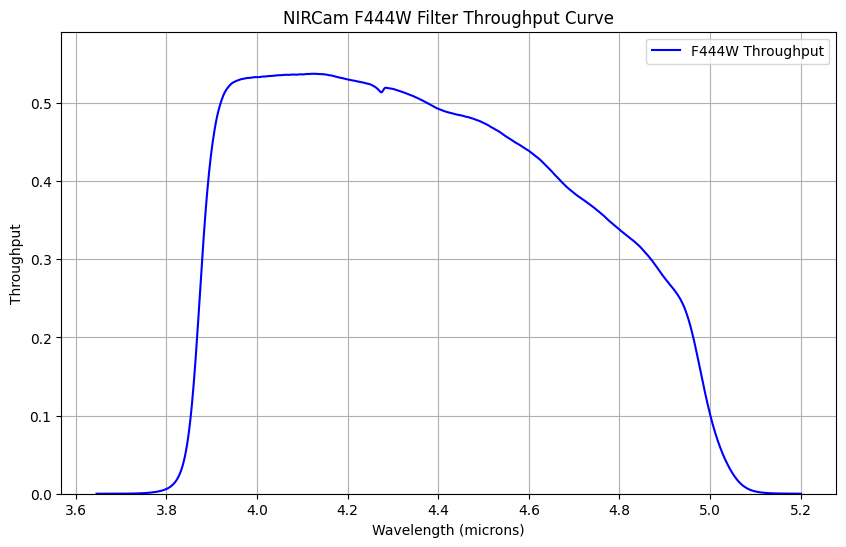

In [12]:
t_waves = nrc.bandpass.wave
t_throughput = nrc.bandpass.throughput

# Plot the throughput curve
plt.figure(figsize=(10, 6))
plt.plot(t_waves/10000, t_throughput, color='blue', label='F444W Throughput')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Throughput')
plt.title('NIRCam F444W Filter Throughput Curve')
plt.ylim(0, max(t_throughput)*1.1)
plt.grid(True)
plt.legend()
plt.show()

In [13]:
import webbpsf_ext

# Create synphot spectrum from BOSZ grid (Bohlin et al 2017, Mészáros et al. 2024, https://archive.stsci.edu/hlsp/bosz)
# In this case, normalized a ~M0V star to 2MASS K'-Band of 7.3 mags
# Stellar properties (Teff=3800K, log_g=4.2) are from Sokal et al (2018, ApJ, 853, 120)
bp_k = webbpsf_ext.bp_2mass('k')
sp = webbpsf_ext.stellar_spectrum('M0V', 7.3, 'vegamag', bp_k, Teff=3800, log_g=4.2, metallicity=0.0)

# You can create arbitrary synphot spectrum from arrays like so:
# sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array([...]), flux=np.array([...]), wave_unit='angstrom', flux_unit='flam')
# wave_unit can be 'angstrom', 'um', 'nm', etc.
# flux_unit can be 'Jy', 'flam' (erg/s/cm^2/Angstrom), 'photlam' (photons/s/cm^2/Angstrom), etc

# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp, binset=bp.waveset)
    print(f"{filt} Flux Density: {obs.effstim('Jy'):.3f} Jy")

sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp.wave), flux=np.array(sp.flux))
sp.convert('flam')  # Convert to erg/s/cm^2/Angstrom
wave = sp.wave
flux = sp.flux

F200W Flux Density: 0.854 Jy
F356W Flux Density: 0.349 Jy
F444W Flux Density: 0.234 Jy


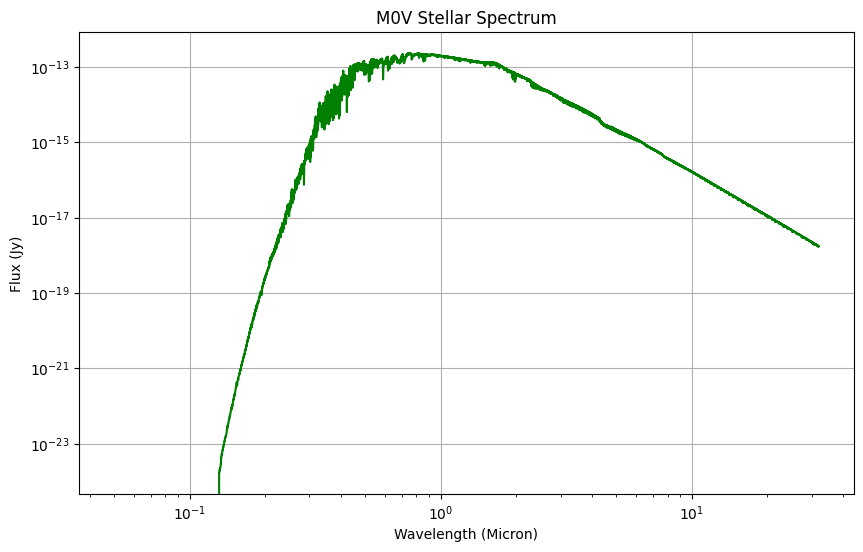

In [14]:
# plotting the flux vs wavelength
plt.figure(figsize=(10, 6))
plt.plot(wave/1e4, flux, color='green')
plt.xlabel('Wavelength (Micron)')
plt.ylabel('Flux (Jy)')
plt.title('M0V Stellar Spectrum')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

Number of data points with 1.0 < λ < 1.8 μm and non-zero errors: 58
Wavelength range for fitting: 1.2390 - 1.6495 μm
Reduced χ²: 6.1884

Fit Results:
Scale factor: 9.713391e-01 ± 8.525840e-03


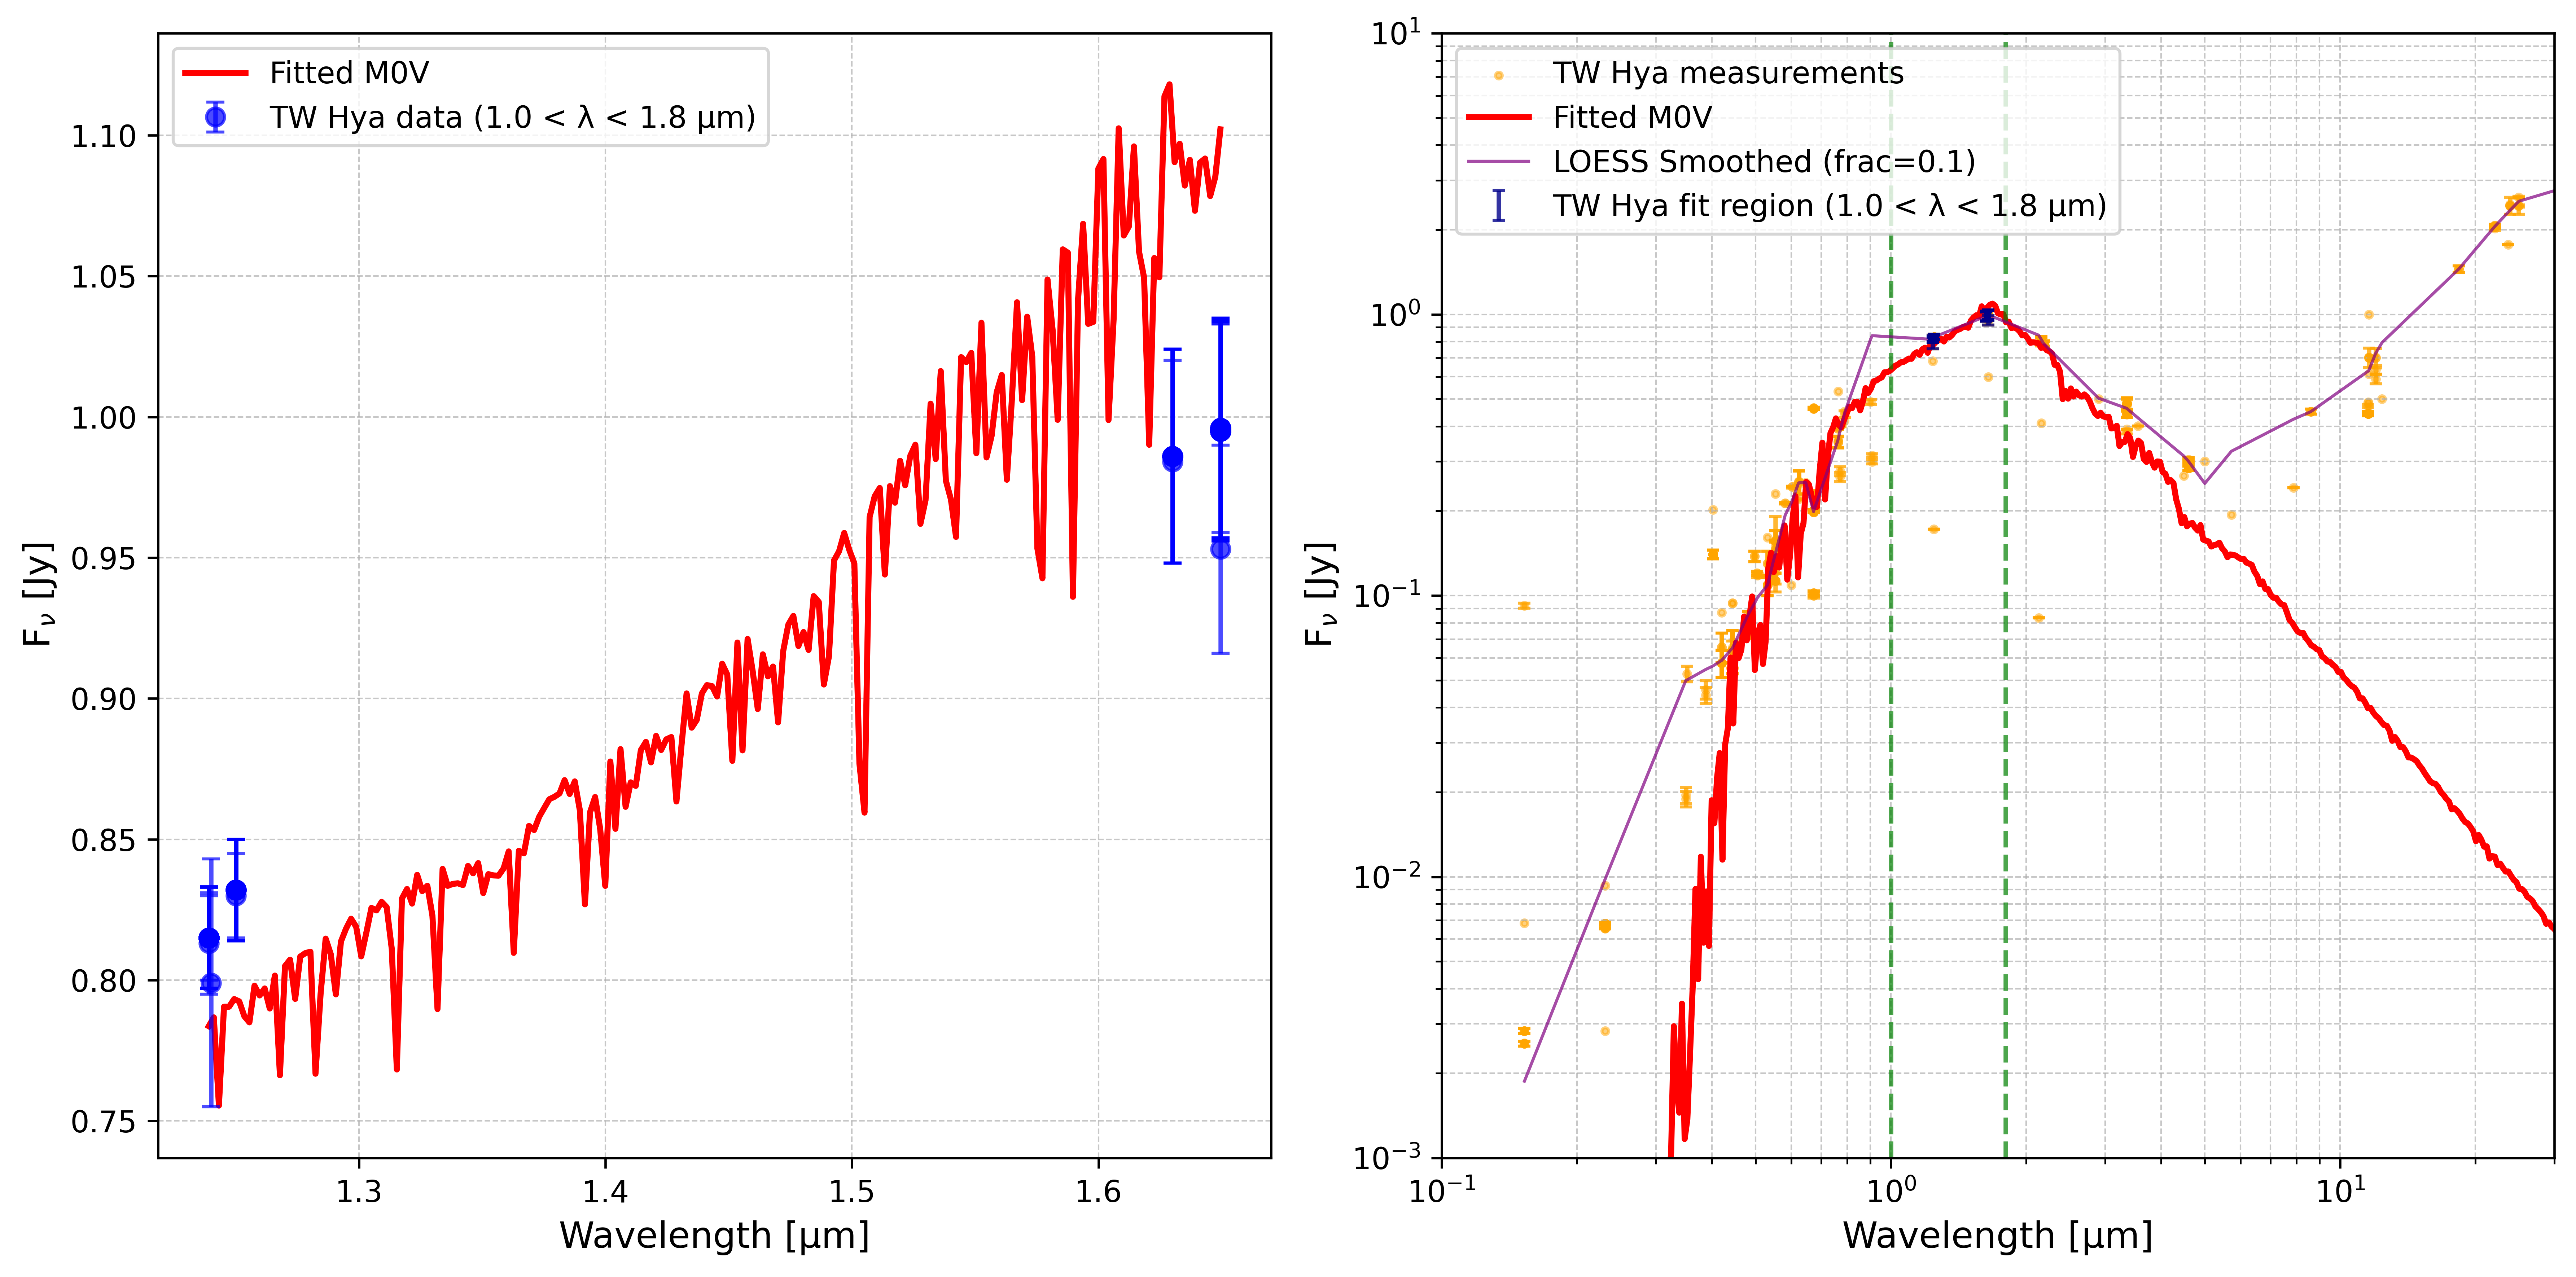


Fitted M0V interpolator created for wavelength range: 0.1000 - 100.0000 μm


In [15]:
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import statsmodels.api as sm

# M0V spectrum
m0v_wavelength_microns = wave/1e4
m0v_flux = flux

# Read tw hya vot file
star_vot = Table.read('twhya.vot')

# Convert frequency to wavelength (microns) for plotting.
star_vot["wavelength"] = (const.c / star_vot["sed_freq"]).to(u.micron)

# Constants
c = 299792458.0  # Speed of light in m/s
Jy_to_Wm2Hz = 1e-26 # Conversion factor for Jansky to W/m^-2/Hz^-1
micron_to_m = 1e-6   # Conversion factor for micron to m

# Extract data from your star_vot
star_wavelength_microns = star_vot["wavelength"]
star_sed_flux_jansky = star_vot["sed_flux"]

# Sort the data by wavelength for smoothing
sorted_indices = np.argsort(star_wavelength_microns)
star_wavelength_microns_sorted = star_wavelength_microns[sorted_indices]
star_sed_flux_jansky_sorted = star_sed_flux_jansky[sorted_indices]

# Smoothing the data using LOESS (Locally Estimated Scatterplot Smoothing)
# The 'frac' parameter controls the smoothness.
# It's the fraction of data used for each local regression.
# Adjust this value (e.g., 0.1 to 0.5) to change smoothness.
frac_value = 0.1
smoothed_star_sed_flux_jansky = sm.nonparametric.lowess(star_sed_flux_jansky_sorted, star_wavelength_microns_sorted, frac=frac_value)
smoothed_x = smoothed_star_sed_flux_jansky[:, 0]
smoothed_y = smoothed_star_sed_flux_jansky[:, 1]
star_flux_wavelengths_interpolator = interp1d(smoothed_x, smoothed_y, kind='linear')

# --- fitting the M0V ---

# Set the cutoff wavelength
cut_off_wavelength_l = 1.0  # microns
cut_off_wavelength = 1.8  # microns

# Create an interpolator for the M0V spectrum (wavelength in microns, flux in erg/s/cm²/Å)
m0v_interpolator = interp1d(m0v_wavelength_microns, m0v_flux, kind='linear', bounds_error=False, fill_value='extrapolate')

# Filter TW Hya data for wavelength < cut_off_wavelength and non-zero errors
mask = (cut_off_wavelength_l < star_vot["wavelength"]) & (star_vot["wavelength"] < cut_off_wavelength) & (star_vot["sed_eflux"] > 0)

tw_hya_wl_fit = star_vot["wavelength"][mask].value  # in microns
tw_hya_flux_fit = star_vot["sed_flux"][mask].value  # in Jy
tw_hya_flux_err_fit = star_vot["sed_eflux"][mask].value  # in Jy

print(f"Number of data points with {cut_off_wavelength_l} < λ < {cut_off_wavelength} μm and non-zero errors: {len(tw_hya_wl_fit)}")
print(f"Wavelength range for fitting: {tw_hya_wl_fit.min():.4f} - {tw_hya_wl_fit.max():.4f} μm")

# Convert M0V flux from F_λ (erg/s/cm²/Å) to F_ν (Jy)
# F_ν = F_λ * (dλ/dν) where dλ/dν = λ²/c
# F_ν = F_λ * (λ²/c) where λ is in cm and c is in cm/s
# Then convert from erg/s/cm²/Hz to Jy (1 Jy = 10^-23 erg/s/cm²/Hz)
def m0v_flux_fnu_jy(wavelength_microns):
    """Convert M0V flux from F_λ [erg/s/cm²/Å] to F_ν [Jy]"""
    flux_flambda = m0v_interpolator(wavelength_microns)  # erg/s/cm²/Å
    wavelength_angstrom = wavelength_microns * 1e4  # Convert microns to Angstroms
    c_cm_per_s = 2.99792458e10  # Speed of light in cm/s
    # For F_λ in erg/s/cm²/Å and conversion to F_ν in erg/s/cm²/Hz:
    # F_ν [erg/s/cm²/Hz] = F_λ [erg/s/cm²/Å] * λ² [Å²] / c [Å/s]
    c_angstrom_per_s = c_cm_per_s * 1e8  # Convert to Å/s
    flux_fnu_erg = flux_flambda * (wavelength_angstrom**2) / c_angstrom_per_s
    
    # Convert to Jy
    flux_fnu_jy = flux_fnu_erg * 1e23  # 1 Jy = 10^-23 erg/s/cm²/Hz
    return flux_fnu_jy

# Define the scaling model: TW Hya flux = scale_factor * M0V flux
def model(wavelength, scale_factor):
    return scale_factor * m0v_flux_fnu_jy(wavelength)

# Perform the fit with error weighting
popt, pcov = curve_fit(model, tw_hya_wl_fit, tw_hya_flux_fit, 
                       sigma=tw_hya_flux_err_fit, p0=[1.0], absolute_sigma=True)

scale_factor = popt[0]
scale_factor_err = np.sqrt(pcov[0, 0])

# Calculate reduced chi-squared
model_flux_fit = model(tw_hya_wl_fit, scale_factor)
chi_squared = np.sum(((tw_hya_flux_fit - model_flux_fit) / tw_hya_flux_err_fit)**2)
dof = len(tw_hya_wl_fit) - 1  # degrees of freedom
reduced_chi_squared = chi_squared / dof
print(f"Reduced χ²: {reduced_chi_squared:.4f}")
# If chi^2 > 1, we inflate the error. If chi^2 < 1, we usually keep the raw error (don't shrink it).
inflation_factor = np.sqrt(reduced_chi_squared) if reduced_chi_squared > 1.0 else 1.0
scale_factor_err *= inflation_factor

print(f"\nFit Results:")
print(f"Scale factor: {scale_factor:.6e} ± {scale_factor_err:.6e}")

# Extend the fitted curve to longer wavelengths
wl_extended = np.logspace(np.log10(0.1), np.log10(100), 500)  # 0.1 to 100 microns
fitted_flux_extended = model(wl_extended, scale_factor)

# Plot the fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

# Left plot: Fit region (λ < cut_off_wavelength)
ax1.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='blue', markersize=6, capsize=3, alpha=0.7,
             label=f'TW Hya data ({cut_off_wavelength_l} < λ < {cut_off_wavelength} μm)', zorder=3)

wl_fit_fine = np.linspace(tw_hya_wl_fit.min(), tw_hya_wl_fit.max(), 200)
fitted_flux_fit = model(wl_fit_fine, scale_factor)
ax1.plot(wl_fit_fine, fitted_flux_fit, 'r-', linewidth=2, 
         label=f'Fitted M0V', zorder=2)

ax1.set_xlabel('Wavelength [μm]', fontsize=12)
ax1.set_ylabel('F$_ν$ [Jy]', fontsize=12)
#ax1.set_title(f'Fit Region: TW Hya vs M0V ({cut_off_wavelength_l} < λ < {cut_off_wavelength} μm)\nχ²/dof = {reduced_chi_squared:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Right plot: Extended to longer wavelengths
# Plot all TW Hya data
ax2.scatter(star_vot["wavelength"], star_vot["sed_flux"],
            s=5, color='orange', alpha=0.5, label='TW Hya measurements', zorder=1)
ax2.errorbar(star_vot["wavelength"], star_vot["sed_flux"], yerr=star_vot["sed_eflux"],linestyle="None",color='orange', markersize=0, capsize=2, alpha=0.8)

# Highlight the fitting region
ax2.errorbar(tw_hya_wl_fit, tw_hya_flux_fit, yerr=tw_hya_flux_err_fit, 
             fmt='o', color='darkblue', markersize=0, capsize=2, alpha=0.8,
             label=f'TW Hya fit region ({cut_off_wavelength_l} < λ < {cut_off_wavelength} μm)', zorder=3)

# Plot the extended fitted M0V spectrum
ax2.plot(wl_extended, fitted_flux_extended, 'r-', linewidth=2, 
         label=f'Fitted M0V', zorder=2)

# Add vertical line at cutoff wavelength
ax2.axvline(cut_off_wavelength_l, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7)
ax2.axvline(cut_off_wavelength, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7)

ax2.set_xlabel('Wavelength [μm]', fontsize=12)
ax2.set_ylabel('F$_ν$ [Jy]', fontsize=12)

# Plot the LOESS smoothed curve
ax2.plot(
    smoothed_x,
    smoothed_y,
    color='purple', # A distinct color for the smooth line
    linewidth=1,
    label=f'LOESS Smoothed (frac={frac_value})',
    alpha=0.7   # Marker transparency
)

#ax2.set_title(f'Extended Fit: TW Hya vs M0V Spectrum\nScale: {scale_factor:.4e} ± {scale_factor_err:.4e}', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-1, 3e1)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(0.001,10)

plt.tight_layout()
plt.show()

# Create interpolator for the fitted extended M0V spectrum
fitted_m0v_interpolator = interp1d(wl_extended, fitted_flux_extended, 
                                    kind='linear', bounds_error=False, fill_value='extrapolate')
print(f"\nFitted M0V interpolator created for wavelength range: {wl_extended.min():.4f} - {wl_extended.max():.4f} μm")

In [16]:
# Export the fitted M0V spectrum to a votable like the original TW Hya votable
fitted_table = Table()
fitted_table['wavelength'] = wl_extended * u.micron
fitted_table['sed_freq'] = (const.c / (wl_extended * u.micron)).to(u.GHz)
fitted_table['sed_flux'] = fitted_flux_extended * u.Jy
# Estimate errors using the uncertainties from the fit
fitted_table['sed_eflux'] = (fitted_flux_extended * (scale_factor_err / scale_factor)) * u.Jy

fitted_table.write('fitted_m0v_TWHya.vot', format='votable', overwrite=True)
print("Fitted M0V spectrum exported to 'fitted_m0v_TWHya.vot'")

Fitted M0V spectrum exported to 'fitted_m0v_TWHya.vot'


In [17]:
# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # remove duplicated wavelengths in smoothed data
    unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
    unique_smoothed_y = smoothed_y[unique_indices]
    sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=unique_smoothed_x, flux=unique_smoothed_y, waveunits='um', fluxunits='Jy')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp)
    print(f"{filt} TW Hya Flux Density: {obs.effstim('Jy'):.3f} Jy")
    
    # fitted flux at filter wavelength
    sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=m0v_wavelength_microns, flux=m0v_flux*scale_factor, waveunits='um', fluxunits='flam')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp)
    print(f"{filt} M0V Flux Density: {obs.effstim('Jy'):.3f} Jy")

F200W TW Hya Flux Density: 0.894 Jy
F200W M0V Flux Density: 0.829 Jy
F356W TW Hya Flux Density: 0.435 Jy
F356W M0V Flux Density: 0.339 Jy
F444W TW Hya Flux Density: 0.337 Jy
F444W M0V Flux Density: 0.227 Jy



Filter   Eff Wave   TW Hya [mJy]       M0V [mJy]          Resid [mJy]        Sig   
F200W    2.009        893.81±24.45      829.37±7.28        64.44±25.51      2.5σ
F356W    3.565        435.19±8.75       338.56±2.97        96.63±9.24      10.5σ
F444W    4.362        336.84±3.03       227.32±2.00       109.53±3.63      30.2σ


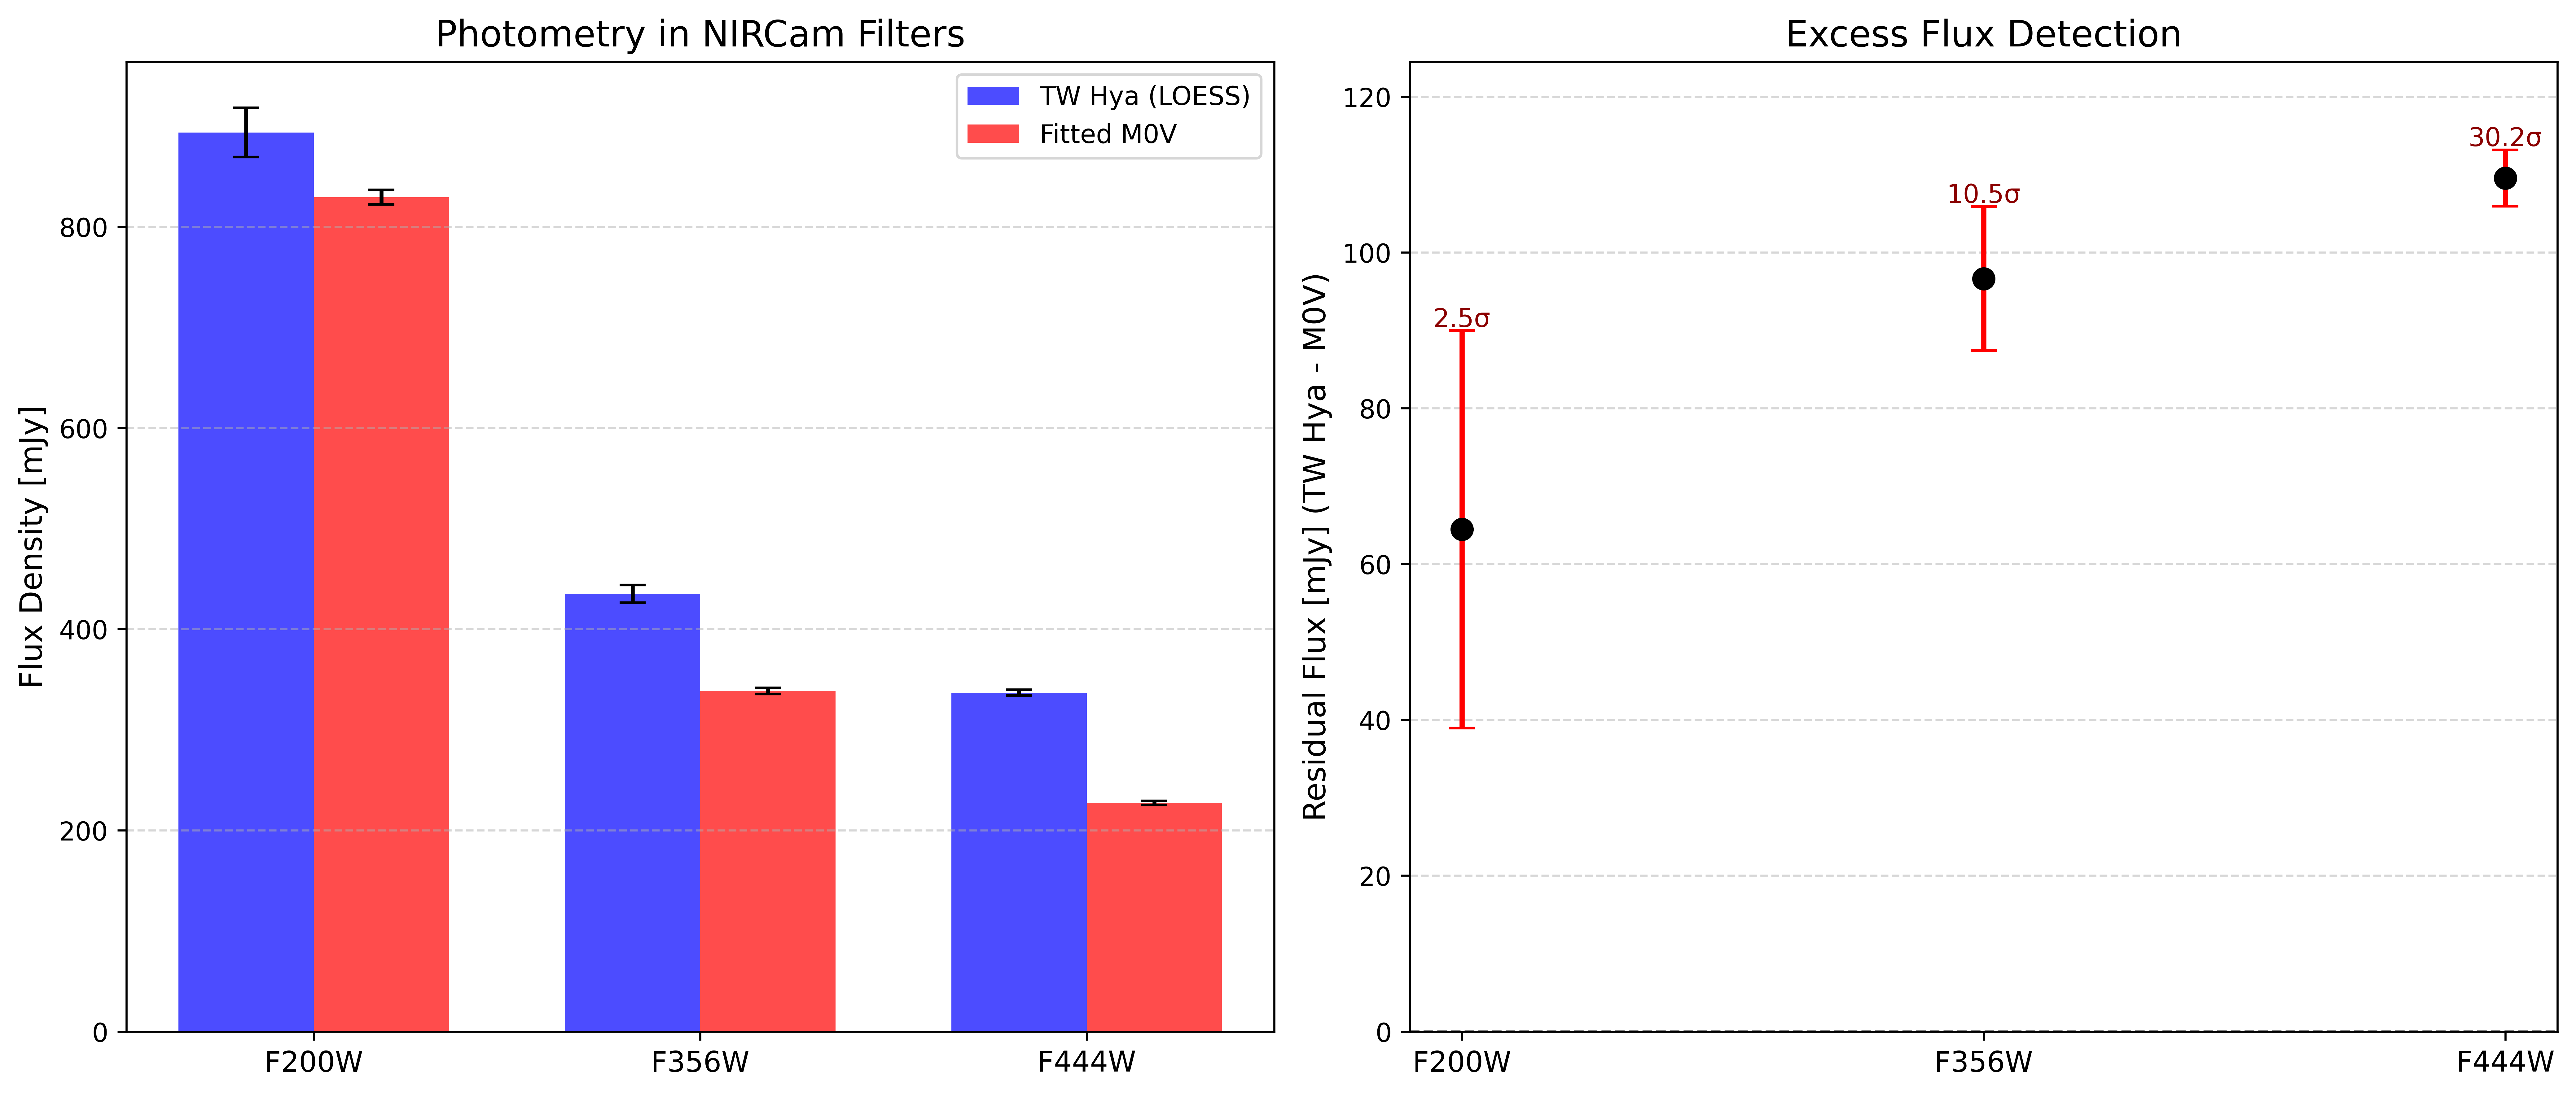

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import webbpsf_ext
from astropy import units as u

# --- 1. Setup Data for Synphot ---

# Clean TW Hya data for Synphot (remove duplicates)
unique_smoothed_x, unique_indices = np.unique(smoothed_x, return_index=True)
unique_smoothed_y = smoothed_y[unique_indices]

# Create Synphot Spectrum for TW Hya (Observed)
# unique_smoothed_x is in microns, unique_smoothed_y is in Jy
sp_twhya = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=unique_smoothed_x, 
    flux=unique_smoothed_y, 
    waveunits='um', 
    fluxunits='Jy'
)

# Create Synphot Spectrum for Fitted M0V (Model)
# We use the original M0V data (assumed in FLAM: erg/s/cm2/A) scaled by the factor
# Note: Ensure m0v_flux is the un-interpolated array or matches m0v_wavelength_microns
sp_m0v = webbpsf_ext.synphot_ext.ArraySpectrum(
    wave=m0v_wavelength_microns, 
    flux=m0v_flux * scale_factor, 
    waveunits='um', 
    fluxunits='flam'
)

# --- 2. Define Filter List and Storage ---

bp_list = ['F200W', 'F356W', 'F444W']
filter_results = {
    'name': [],
    'wavelength': [],
    'twhya_flux': [],
    'twhya_err': [],
    'm0v_flux': [],
    'm0v_err': [],
    'residual': [],
    'resid_err': [],
    'sigma': []
}

print("\n" + "="*90)
print(f"{'Filter':<8} {'Eff Wave':<10} {'TW Hya [mJy]':<18} {'M0V [mJy]':<18} {'Resid [mJy]':<18} {'Sig':<6}")
print("="*90)

# --- 3. Loop Through Filters ---

for filt in bp_list:
    # Load Bandpass
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    
    # Get Effective Wavelength (pivot) and Width (Rectangular approximation)
    eff_wave = bp.pivot().to(u.micron).value
    try:
        # Try to get rectangular width, fallback to approximation if needed
        bp_width = bp.rectwidth().to(u.micron).value
    except:
        bp_width = eff_wave * 0.15 # Fallback approximation
    
    # --- A. Calculate Integrated Fluxes (effstim) ---
    # Observe TW Hya
    obs_twhya = webbpsf_ext.synphot_ext.Observation(sp_twhya, bp)
    flux_twhya_jy = obs_twhya.effstim('Jy')
    
    # Observe M0V Model
    obs_m0v = webbpsf_ext.synphot_ext.Observation(sp_m0v, bp)
    flux_m0v_jy = obs_m0v.effstim('Jy')
    
    # --- B. Calculate Robust Errors for this Filter ---
    
    ## 1. M0V Model Error (Propagated from fit)
    flux_m0v_err = flux_m0v_jy * (scale_factor_err / scale_factor)
    
    # 2. TW Hya Error Components
    # We look for data points within the "Rectangular Width" of the filter
    mask_band = np.abs(star_vot["wavelength"].value - eff_wave) < (bp_width / 2.0)
    flux_in_band = star_vot["sed_flux"].value[mask_band]
    err_in_band = star_vot["sed_eflux"].value[mask_band]
    # Filter valid points
    N = 0 # Number of valid points
    penalty = 0.0 # Penalty for no points in band
    valid = (err_in_band > 0) & (~np.isnan(flux_in_band))
    flux_filt = flux_in_band[valid]
    err_filt = err_in_band[valid]
        
    if len(flux_filt) > 1:
        pass
    else:
        N = 1
        # Fallback if < 2 points in band
        #print(f"Filter {filt}: Not enough data points in band for statistical error, using nearby points.")
        # Use nearest 20 points outside the band for error estimate
        all_flux = star_vot["sed_flux"].value
        all_err = star_vot["sed_eflux"].value
        all_wl = star_vot["wavelength"].value
        # Exclude points without valid errors
        valid_all = all_err > 0
        all_flux = all_flux[valid_all]
        all_err = all_err[valid_all]
        all_wl = all_wl[valid_all]
        # Find indices of nearest 20 points to eff_wave
        distances = np.abs(all_wl - eff_wave)
        nearest_indices = np.argsort(distances)[:10]
        if len(flux_filt) == 0:
            # If no points in band, penalty with the distance to the nearest point * slope
            wl_nearby = eff_wave * np.array([0.99, 1.01])
            flux_nearby = fitted_m0v_interpolator(wl_nearby)
            gradient = np.abs(np.diff(flux_nearby)[0]) / (0.02 * eff_wave)
            penalty = gradient * np.min(distances)
        flux_filt = all_flux[nearest_indices]
        err_filt = all_err[nearest_indices]
    
    # Robust Scatter (MAD) to remove outliers inside the band
    median_f = np.nanmedian(flux_filt)
    mad = np.nanmedian(np.abs(flux_filt - median_f))
    if mad > 0:
        not_outlier = np.abs(flux_filt - median_f) < 3.0 * 1.4826 * mad
        flux_clean = flux_filt[not_outlier]
        err_clean = err_filt[not_outlier]
    else:
        flux_clean, err_clean = flux_filt, err_filt
        
    if N == 0:
        N = len(flux_clean)
    #print(f"Filter {filt}: Found {N} valid data points in band for statistical error calculation.")
    # Standard Error of the Mean (Scatter / sqrt(N))
    sem_scatter = np.std(flux_clean, ddof=1) / np.sqrt(N) if N > 1 else 0
    sem_meas = np.nanmedian(err_clean) / np.sqrt(N) if N > 0 else 0
    flux_twhya_err = np.sqrt(sem_scatter**2 + sem_meas**2 + penalty**2)

    # --- C. Calculate Residuals ---
    residual = flux_twhya_jy - flux_m0v_jy
    resid_err = np.sqrt(flux_twhya_err**2 + flux_m0v_err**2)
    sigma = residual / resid_err if resid_err > 0 else 0
    
    # Store Data
    filter_results['name'].append(filt)
    filter_results['wavelength'].append(eff_wave)
    filter_results['twhya_flux'].append(flux_twhya_jy)
    filter_results['twhya_err'].append(flux_twhya_err)
    filter_results['m0v_flux'].append(flux_m0v_jy)
    filter_results['m0v_err'].append(flux_m0v_err)
    filter_results['residual'].append(residual)
    filter_results['resid_err'].append(resid_err)
    filter_results['sigma'].append(sigma)
    
    print(f"{filt:<8} {eff_wave:<10.3f} {flux_twhya_jy*1000:>8.2f}±{flux_twhya_err*1000:<8.2f} "
          f"{flux_m0v_jy*1000:>8.2f}±{flux_m0v_err*1000:<8.2f} "
          f"{residual*1000:>8.2f}±{resid_err*1000:<8.2f} {sigma:>5.1f}σ")

print("="*90)

# --- 4. Plotting the Results ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=600)

# X-axis setup
x_pos = np.arange(len(bp_list))
labels = filter_results['name']

# --- PLOT 1: Flux Comparison (Bar Chart) ---
width = 0.35
ax1.bar(x_pos - width/2, np.array(filter_results['twhya_flux'])*1000, width, 
        yerr=np.array(filter_results['twhya_err'])*1000, capsize=5, 
        label='TW Hya (LOESS)', color='blue', alpha=0.7)

ax1.bar(x_pos + width/2, np.array(filter_results['m0v_flux'])*1000, width, 
        yerr=np.array(filter_results['m0v_err'])*1000, capsize=5, 
        label='Fitted M0V', color='red', alpha=0.7)

ax1.set_ylabel('Flux Density [mJy]', fontsize=12)
ax1.set_title('Photometry in NIRCam Filters', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT 2: Residuals (Scatter with Error Bars) ---
# Convert to mJy for easier reading
y_res = np.array(filter_results['residual']) * 1000
y_err = np.array(filter_results['resid_err']) * 1000

ax2.errorbar(x_pos, y_res, yerr=y_err, fmt='o', color='k', 
             ecolor='red', elinewidth=2, capsize=5, markersize=8, label='Residual')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add text annotations for Sigma
for i, sig in enumerate(filter_results['sigma']):
    ax2.annotate(f'{sig:.1f}σ', (x_pos[i], y_res[i] + y_err[i] + 0.5), 
                 ha='center', color='darkred', fontsize=10)

ax2.set_ylabel('Residual Flux [mJy] (TW Hya - M0V)', fontsize=12)
ax2.set_title('Excess Flux Detection', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, max(y_res + y_err) * 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# Copy final flux results from Photometry_rust.ipynb
hpfrdi_fluxes = np.array([8.261598, 2.186898, 1.159143]) # F200W, F356W, F444W in mJy
hpfrdi_efluxes = np.array([0.004021, 0.004102, 0.005825])

deconv_fluxes = np.array([19.935692, 3.419619, 2.738869]) # F200W, F356W, F444W in mJy
deconv_efluxes = np.array([0.313885, 0.091031, 0.059583])

hpfrdi_flux_throughput_recover = np.array([22.973305, 6.241253, 3.302085]) # F200W, F356W, F444W in mJy
hpfrdi_eflux_throughput_recover = np.array([0.066352, 0.112315, 0.025245])


Disk/Star Flux Ratio Analysis (Using Synthetic Photometry)
Filter: F200W (2.01 µm)
  Stellar Flux: 829.37 mJy
  Ratio (HPFRDI):      0.009961 ± 0.000088
  Ratio (Deconvolved): 0.024037 ± 0.000433
--------------------------------------------------
Filter: F356W (3.57 µm)
  Stellar Flux: 338.56 mJy
  Ratio (HPFRDI):      0.006459 ± 0.000058
  Ratio (Deconvolved): 0.010100 ± 0.000283
--------------------------------------------------
Filter: F444W (4.36 µm)
  Stellar Flux: 227.32 mJy
  Ratio (HPFRDI):      0.005099 ± 0.000052
  Ratio (Deconvolved): 0.012049 ± 0.000283
--------------------------------------------------


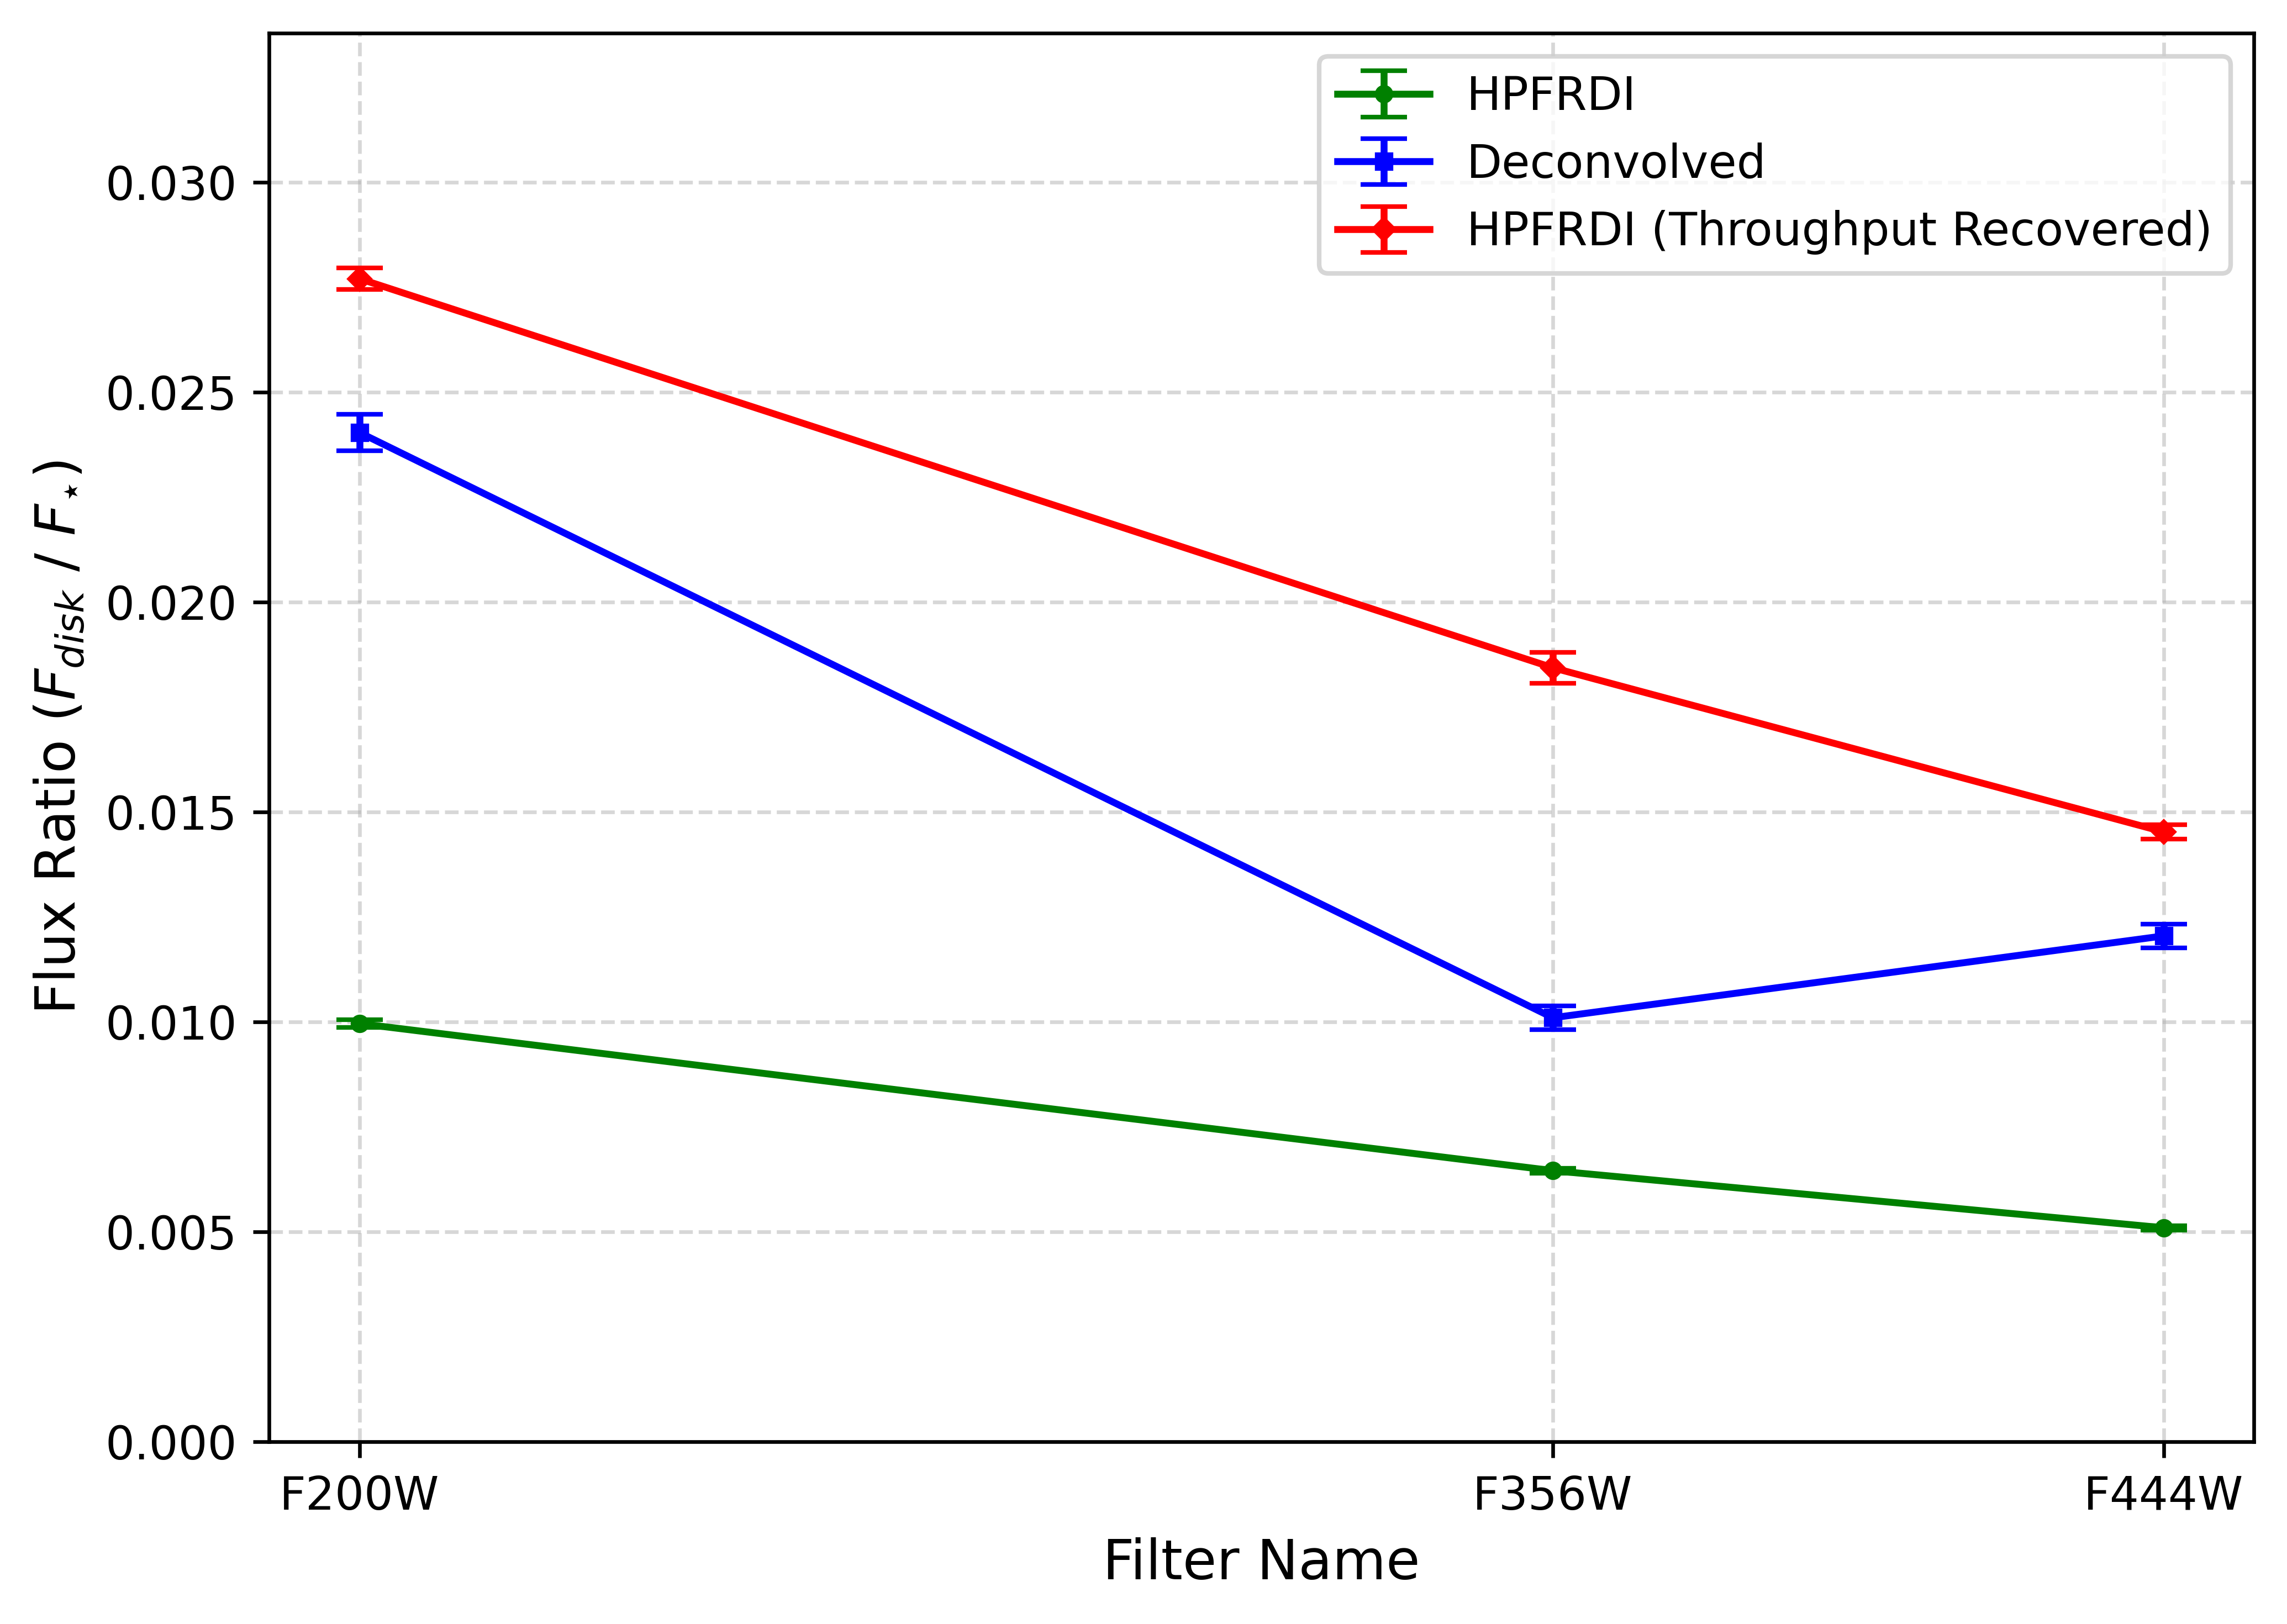

In [20]:
# --- 1. Extract values from previous results ---
# Effective wavelengths and integrated fluxes/errors
filter_names = filter_results['name']
wavelengths = np.array(filter_results['wavelength'])
st_fluxes = np.array(filter_results['m0v_flux'])  # In Jy
st_errs = np.array(filter_results['m0v_err'])    # In Jy

num_filters = len(filter_names)

# Initialize storage arrays
hpfrdi_disk_star_ratios = np.zeros(num_filters)
hpfrdi_disk_star_ratios_err = np.zeros(num_filters)
deconv_disk_star_ratios = np.zeros(num_filters)
deconv_disk_star_ratios_err = np.zeros(num_filters)
hpfrdi_throughput_recover_disk_star_ratios = np.zeros(num_filters)
hpfrdi_throughput_recover_disk_star_ratios_err = np.zeros(num_filters)

print("\nDisk/Star Flux Ratio Analysis (Using Synthetic Photometry)")
print("="*90)

# --- 2. Calculate Ratios ---
# Assuming hpfrdi_fluxes and deconv_fluxes are in mJy
for i in range(num_filters):
    filt = filter_names[i]
    wl = wavelengths[i]
    f_star = st_fluxes[i]
    e_star = st_errs[i]
    
    # A. HPFRDI Ratio
    # Formula: (Disk_mJy / 1000) / Star_Jy
    hpfrdi_disk_star_ratios[i] = (hpfrdi_fluxes[i] / 1000.0) / f_star
    hpfrdi_disk_star_ratios_err[i] = hpfrdi_disk_star_ratios[i] * np.sqrt(
        (hpfrdi_efluxes[i] / hpfrdi_fluxes[i])**2 + (e_star / f_star)**2
    )
    
    # B. HPFRDI with Throughput Recovery
    hpfrdi_throughput_recover_disk_star_ratios[i] = (hpfrdi_flux_throughput_recover[i] / 1000.0) / f_star
    hpfrdi_throughput_recover_disk_star_ratios_err[i] = hpfrdi_throughput_recover_disk_star_ratios[i] * np.sqrt(
        (hpfrdi_eflux_throughput_recover[i] / hpfrdi_flux_throughput_recover[i])**2 + (e_star / f_star)**2
    )
    
    # C. Deconvolved Ratio
    deconv_disk_star_ratios[i] = (deconv_fluxes[i] / 1000.0) / f_star
    deconv_disk_star_ratios_err[i] = deconv_disk_star_ratios[i] * np.sqrt(
        (deconv_efluxes[i] / deconv_fluxes[i])**2 + (e_star / f_star)**2
    )

    print(f"Filter: {filt} ({wl:.2f} µm)")
    print(f"  Stellar Flux: {f_star*1000:.2f} mJy")
    print(f"  Ratio (HPFRDI):      {hpfrdi_disk_star_ratios[i]:.6f} ± {hpfrdi_disk_star_ratios_err[i]:.6f}")
    print(f"  Ratio (Deconvolved): {deconv_disk_star_ratios[i]:.6f} ± {deconv_disk_star_ratios_err[i]:.6f}")
    print("-" * 50)

# --- 3. Plotting ---
plt.figure(figsize=(7, 5), dpi=600)

# Use errorbar with filter names as x-ticks
plt.errorbar(wavelengths, hpfrdi_disk_star_ratios, yerr=hpfrdi_disk_star_ratios_err, 
             marker='o', markersize=3, capsize=5, linestyle='-', color='green', label='HPFRDI')

plt.errorbar(wavelengths, deconv_disk_star_ratios, yerr=deconv_disk_star_ratios_err, 
             marker='s', markersize=3, capsize=5, linestyle='-', color='blue', label='Deconvolved')

plt.errorbar(wavelengths, hpfrdi_throughput_recover_disk_star_ratios, yerr=hpfrdi_throughput_recover_disk_star_ratios_err, 
             marker='D', markersize=3, capsize=5, linestyle='-', color='red', label='HPFRDI (Throughput Recovered)')

# Formatting
plt.xlabel(r'Filter Name', fontsize=12)
plt.ylabel(r'Flux Ratio ($F_{disk}$ / $F_{\star}$)', fontsize=12)
#plt.title('Disk-to-Star Contrast Ratios', fontsize=14)

# Set X-ticks to the specific filter wavelengths
plt.xticks(wavelengths, filter_names)

# Dynamic Y-limit
max_val = max(np.max(hpfrdi_throughput_recover_disk_star_ratios + hpfrdi_throughput_recover_disk_star_ratios_err),
              np.max(deconv_disk_star_ratios + deconv_disk_star_ratios_err))
plt.ylim(0, max_val * 1.2)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

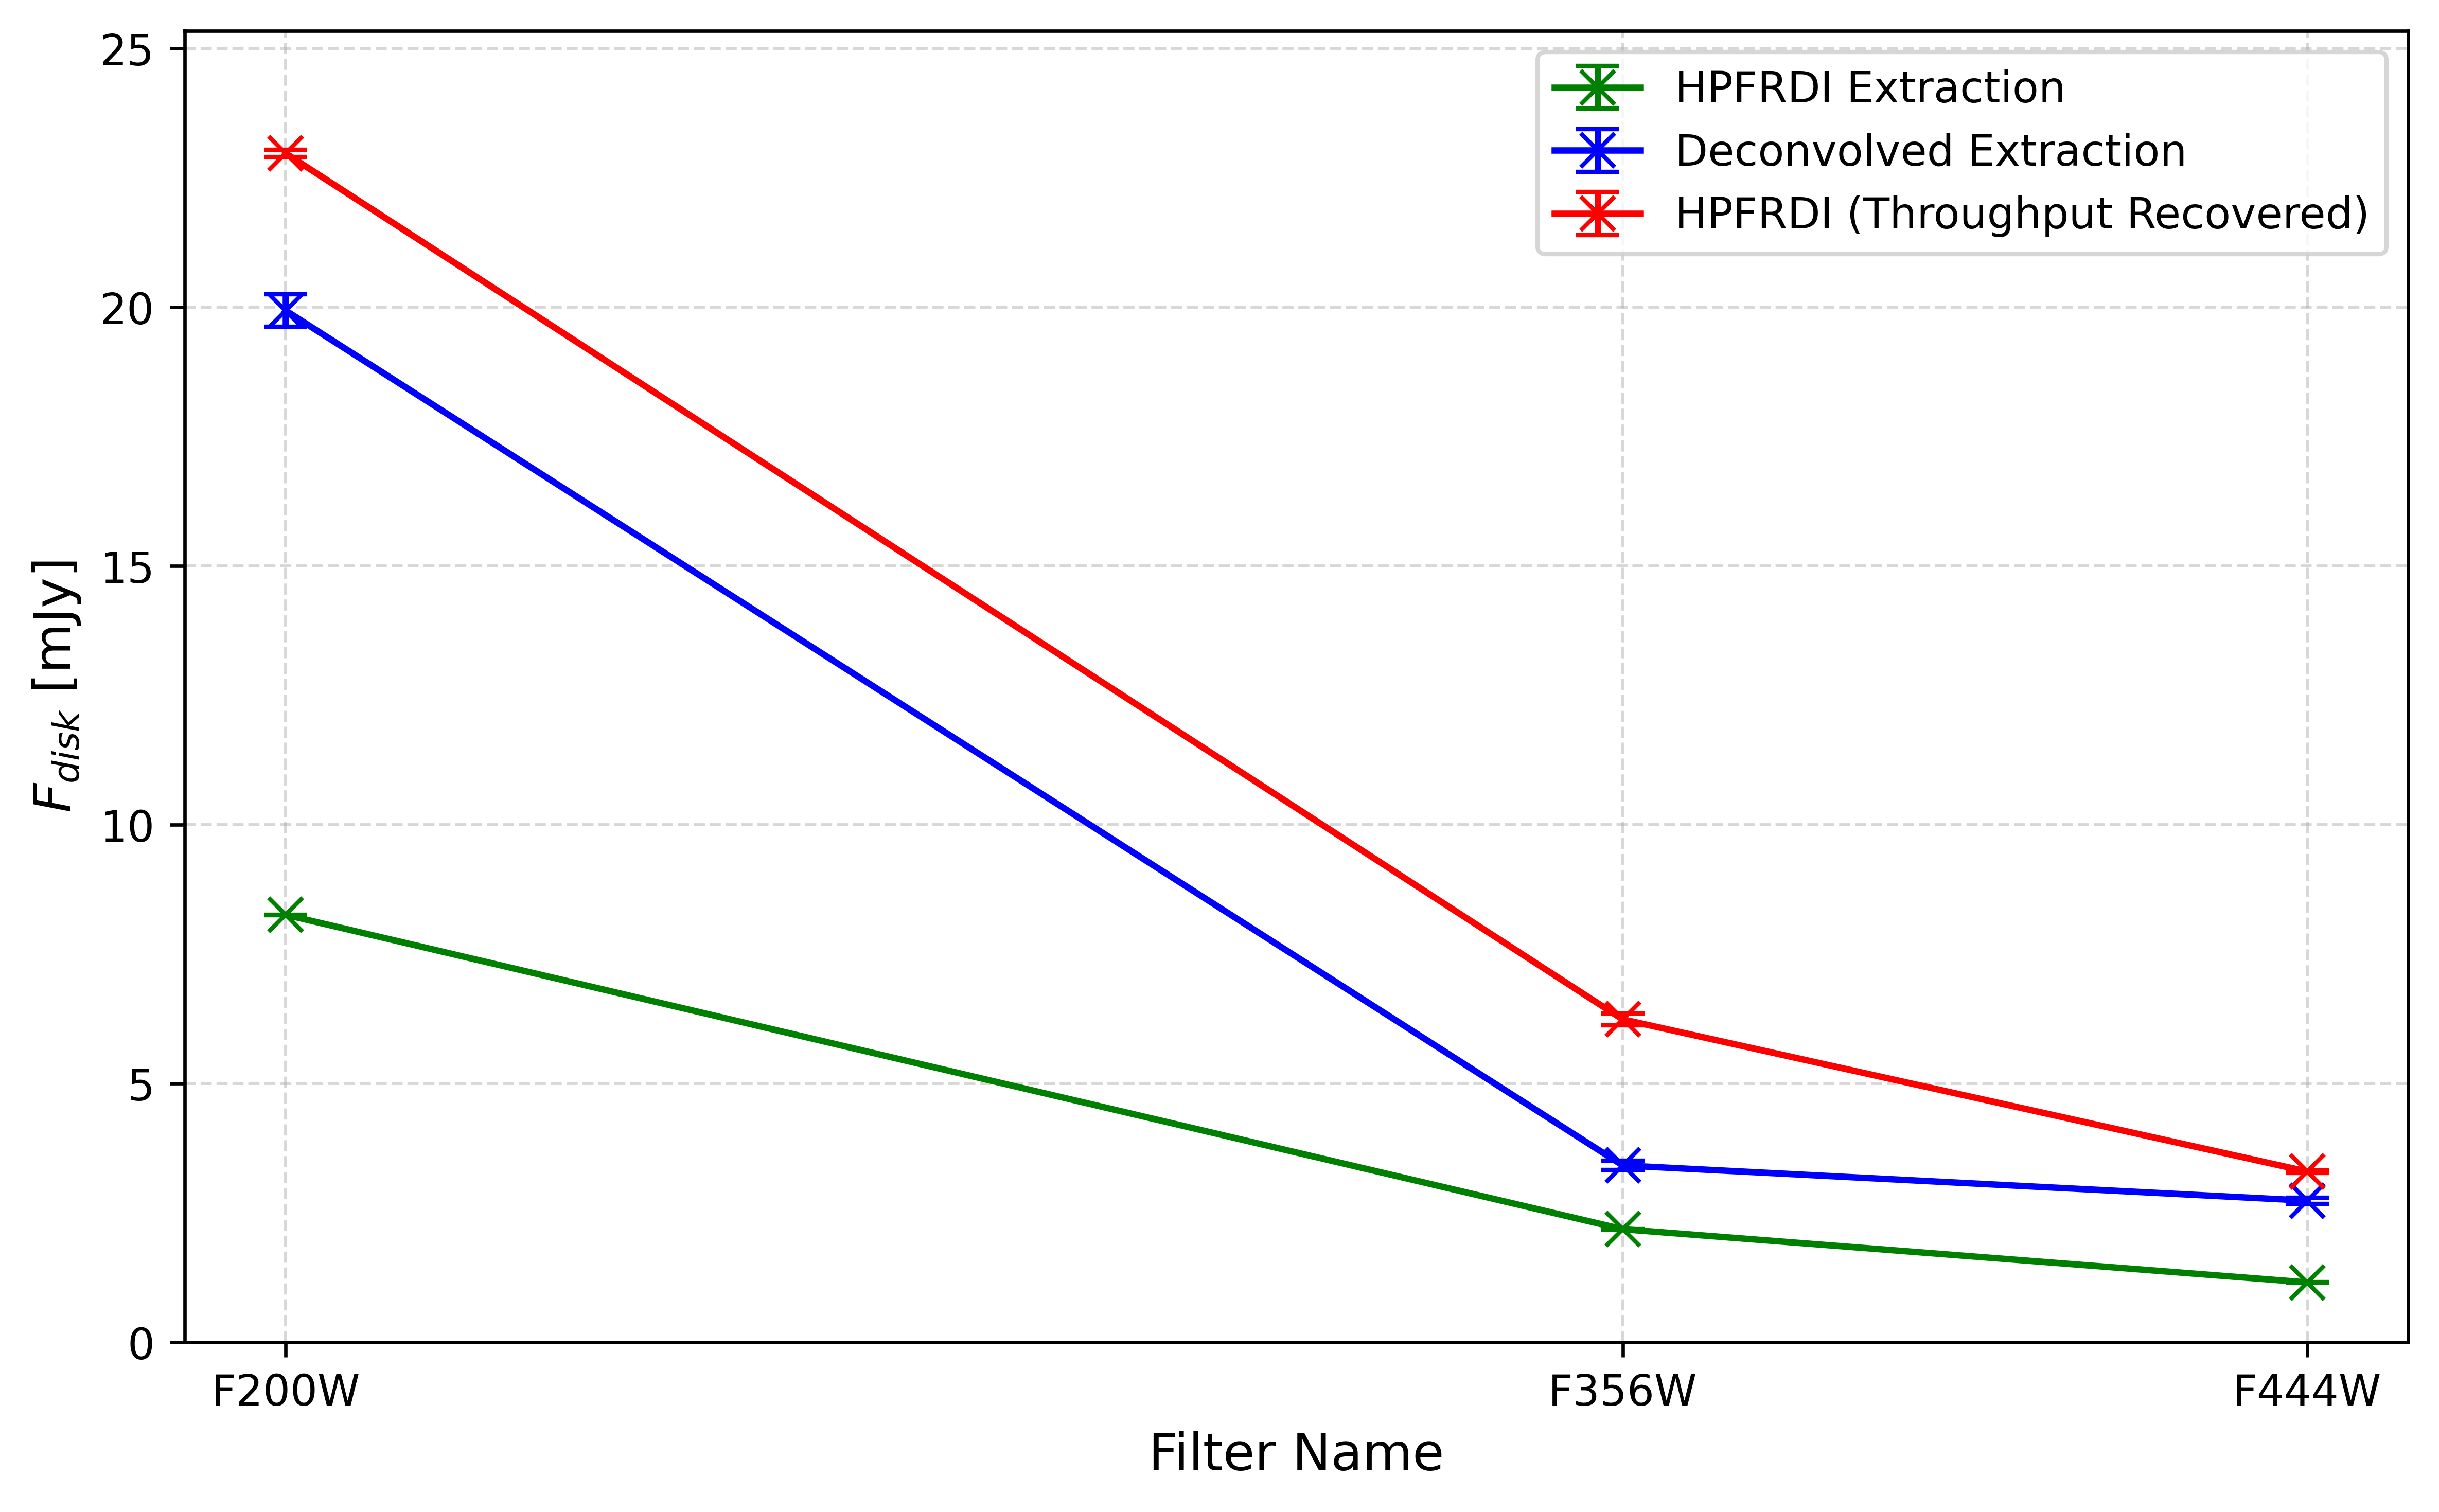

In [21]:
# --- 1. Extract Wavelengths and SED Residuals from Method 2 ---
filter_names = filter_results['name']
wavelengths = np.array(filter_results['wavelength'])

# The 'residual' in filter_results is (TW Hya - M0V), which represents the 
# disk flux detected via SED subtraction.
sed_excess_flux_mjy = np.array(filter_results['residual']) * 1000
sed_excess_err_mjy = np.array(filter_results['resid_err']) * 1000

# --- 2. Plotting ---
plt.figure(figsize=(8, 5), dpi=600)

# Plot HPFRDI results
plt.errorbar(wavelengths, hpfrdi_fluxes, yerr=hpfrdi_efluxes, 
             marker='x', markersize=8, capsize=5, linestyle='-', 
             color='green', label='HPFRDI Extraction')

# Plot Deconvolved results
plt.errorbar(wavelengths, deconv_fluxes, yerr=deconv_efluxes, 
             marker='x', markersize=8, capsize=5, linestyle='-', 
             color='blue', label='Deconvolved Extraction')

# Plot Throughput Recovered HPFRDI results
plt.errorbar(wavelengths, hpfrdi_flux_throughput_recover, yerr=hpfrdi_eflux_throughput_recover, 
             marker='x', markersize=8, capsize=5, linestyle='-', 
             color='red', label='HPFRDI (Throughput Recovered)')

# Formatting
plt.xlabel(r'Filter Name', fontsize=12)
plt.ylabel(r'$F_{disk}$ [mJy]', fontsize=12)
#plt.title('Disk Flux Extraction Comparison', fontsize=14)

# Set X-ticks to filter names for clarity
plt.xticks(wavelengths, filter_names)

# Adjust Y-limit to fit all data plus error bars
max_y = max(
    np.max(hpfrdi_fluxes + hpfrdi_efluxes), 
    np.max(deconv_fluxes + deconv_efluxes),
    np.max(hpfrdi_flux_throughput_recover + hpfrdi_eflux_throughput_recover)
)
plt.ylim(0, max_y * 1.1)

plt.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.5)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()